[[0.0000e+00 2.1377e+00]
 [1.9333e-14 2.1540e+00]
 [3.8667e-14 2.1959e+00]
 ...
 [3.9535e-11 8.4526e+00]
 [3.9555e-11 8.2139e+00]
 [3.9574e-11 7.9792e+00]]


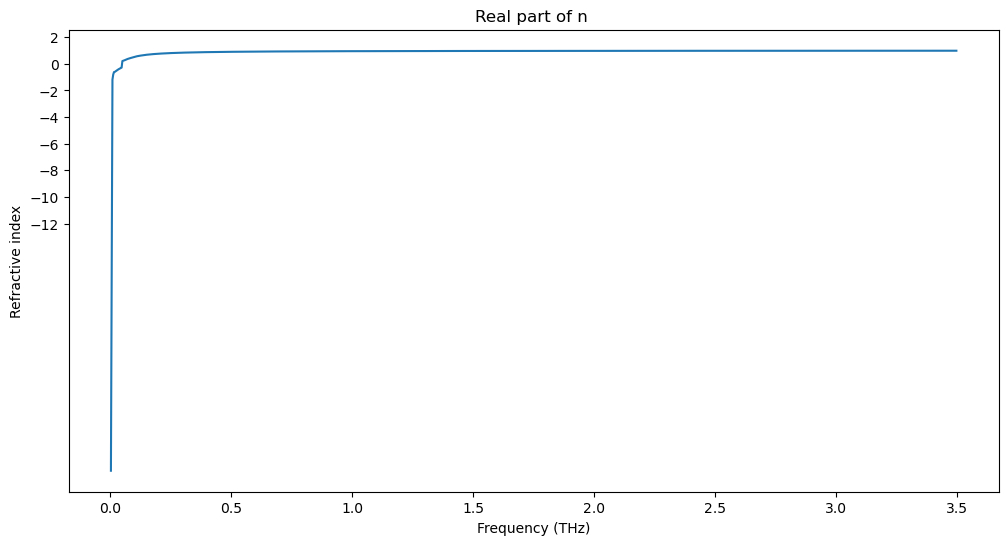

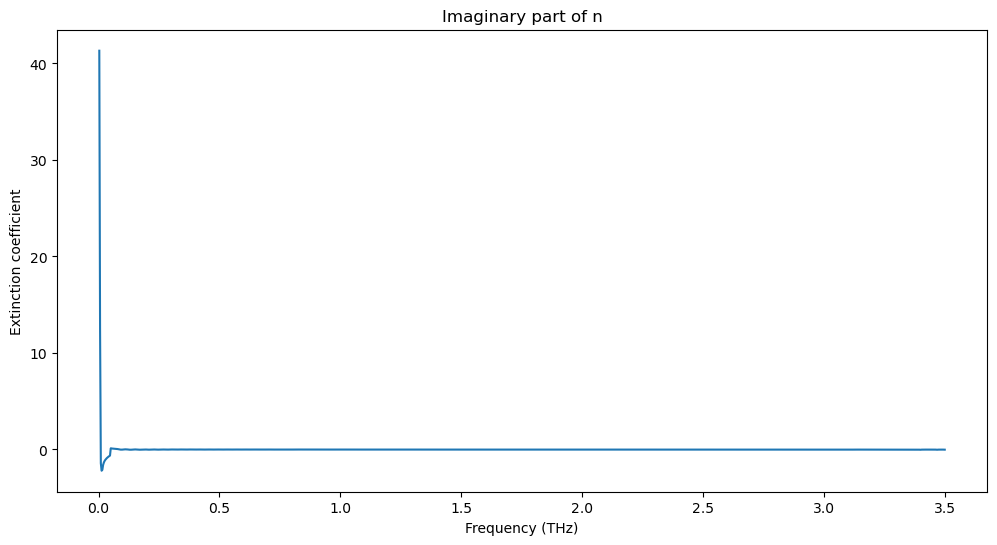

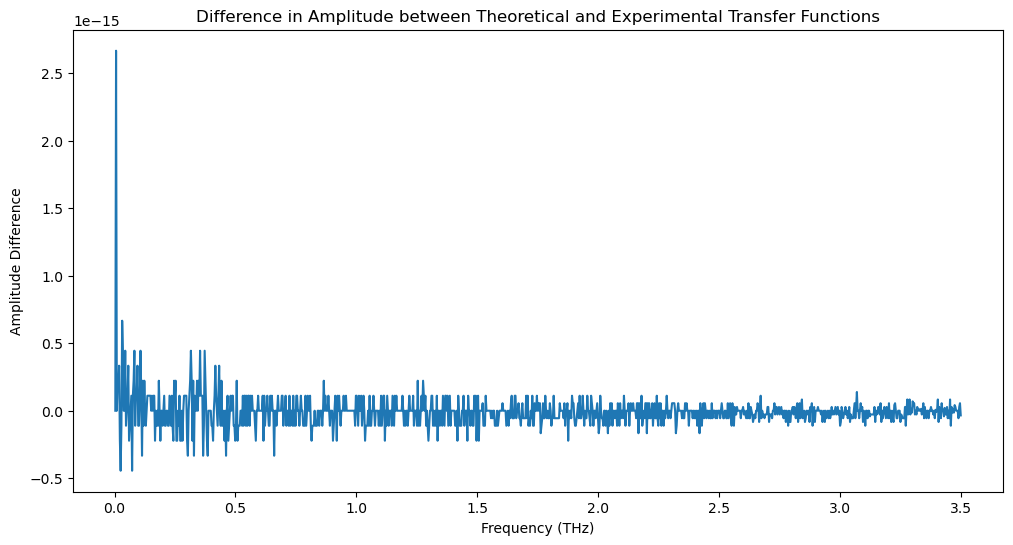

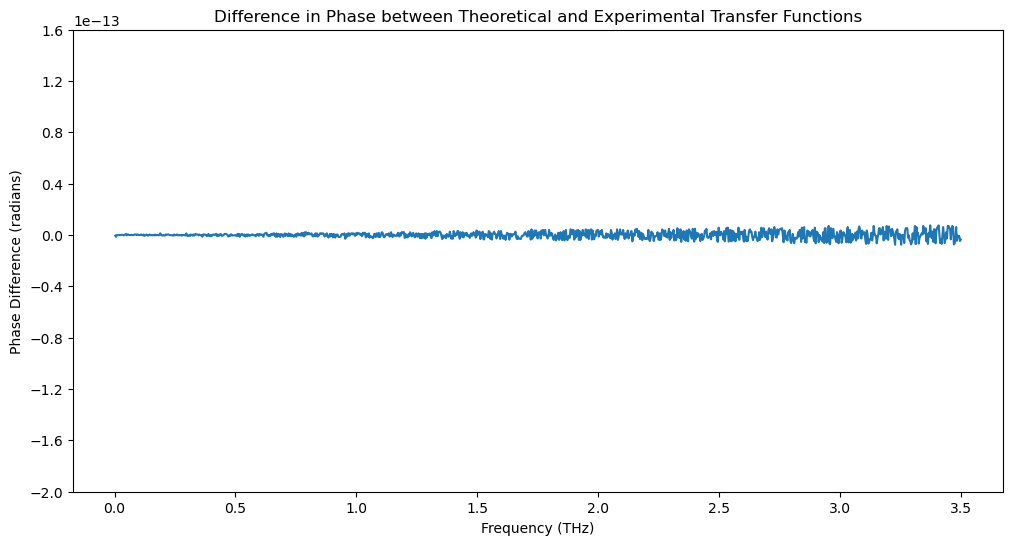

In [10]:
import numpy as np
import matplotlib.pyplot as plt

#LOAD DATA
datar = np.loadtxt("/Users/vasilis/Dropbox/Mac/Documents/GitHub/Vasilis/Soton Code/Christina Latifi/2mmR.dat", delimiter=",")
datas = np.loadtxt("/Users/vasilis/Dropbox/Mac/Documents/GitHub/Vasilis/Soton Code/Christina Latifi/2mmS.dat", delimiter=",")
print(datar)
ts = datas[:, 0]
tr = datar[:, 0]
sr = datar[:, 1]
ss = datas[:, 1]

#CONSTANTS
L=2e-3
c=3e8

#INTERPOLATION
startt = 0
endt = 4.6116 * 10**-11
dt = min(np.mean(np.diff(ts)), np.mean(np.diff(tr)))
t = np.arange(startt, endt + dt, dt)

sr = np.interp(t, tr, sr, left=0, right=0)
ss = np.interp(t, ts, ss, left=0, right=0)

# FFT
fftr = np.fft.fft(sr, 16384)
ffts = np.fft.fft(ss, 16384)
freq = np.fft.fftfreq(16384, dt)

#MASK
mask = (freq > 0) & (freq < 3.5 * 10**12)
fftr = fftr[mask]
ffts = ffts[mask]
freq = freq[mask]

#TRANSFER FUNCTION
tf = ffts / fftr
phase_unwrapped = np.unwrap(np.angle(tf))
phase_unwrapped -= phase_unwrapped-2
#print(phase_unwrapped[0])

#DEFINE FUNCTIONS
def F(n, f, lnH_exp):
    lnH_th = np.log((4 * n) / ((1 + n) ** 2)) - 1j * L * (2 * np.pi * f) * (n - 1) / c
    return lnH_th - lnH_exp

def G(n, f):
    return 1 / n - 2 / (1 + n) - 1j * L * (2 * np.pi * f) / c

def n_r(f, lnH_exp, n_0, iterations=50, tolerance=1e-12):
    n = n_0
    for _ in range(iterations):
        F_ = F(n, f, lnH_exp)
        G_ = G(n, f)
        n = n - F_/G_
        if abs(F_/G_) < tolerance:
            break
    return n

n_0 = 2 + 0.05j
n_ = []

#NEWTON RAPHSON
for i, f in enumerate(freq):
    lnH_exp = np.log(np.abs(tf[i])) + 1j * phase_unwrapped[i] 
    n = n_r(f, lnH_exp, n_0) 
    n_.append(n)

n_= np.array(n_)

# DIFFERENCE BETWEEN TRANSFER FUNCTIONS
H_th = (4 * n_) / ((1 + n_) ** 2) * np.exp(-1j * 2e-3 * 2 * np.pi * freq * (n_ - 1) / 3e8)
amp_diff = np.abs(H_th)-np.abs(tf)
phase_diff = np.unwrap(np.angle(H_th)) - phase_unwrapped


np.savetxt("n_0.txt", np.column_stack((freq, np.real(n_), np.imag(n_))))
np.savetxt("amp_diff_0.txt", np.column_stack((freq, amp_diff)))
np.savetxt("phase_diff_0.txt", np.column_stack((freq, phase_diff)))


# PLOT REAL OF COMPLEX REFRACTIVE INDEX
plt.figure(figsize=(12, 6))
plt.plot(freq * 10**-12, np.real(n_), label="Real(n)")
plt.title("Real part of n ")
plt.xlabel("Frequency (THz)")
plt.ylabel("Refractive index")
plt.yticks(np.arange(-12,4,2))
#plt.ylim(1.9,2.1)

# PLOT IMAGINARY OF COMPLEX REFRACTIVE INDEX
plt.figure(figsize=(12, 6))
plt.plot(freq * 10**-12, np.imag(n_), label="Imaginary(n)")
plt.title("Imaginary part of n")
plt.ylabel("Extinction coefficient")
plt.xlabel("Frequency (THz)")
#plt.ylim(-0.5,0.5)

# PLOT AMPLITUDE DIFFERENCE OF TRANSFER FUNCTIONS
plt.figure(figsize=(12, 6))
plt.plot(freq * 10**-12, amp_diff)
plt.xlabel("Frequency (THz)")
plt.ylabel("Amplitude Difference")
plt.title("Difference in Amplitude between Theoretical and Experimental Transfer Functions")


# PLOT  PHASE DIFFERENCE OF TRANSFER FUNCTIONS
plt.figure(figsize=(12, 6))
plt.plot(freq * 10**-12, phase_diff)
plt.xlabel("Frequency (THz)")
plt.ylabel("Phase Difference (radians)")
plt.title("Difference in Phase between Theoretical and Experimental Transfer Functions")
plt.yticks(np.arange(-20e-14,20e-14,4e-14))
plt.show()


In [11]:
print(datar)


[[0.0000e+00 2.1377e+00]
 [1.9333e-14 2.1540e+00]
 [3.8667e-14 2.1959e+00]
 ...
 [3.9535e-11 8.4526e+00]
 [3.9555e-11 8.2139e+00]
 [3.9574e-11 7.9792e+00]]
